<a href="https://colab.research.google.com/github/Danyal288/Data-Analytics-project/blob/main/Digiskill_mini_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

#setting visualizations

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
print('All libraries imported successfully')



All libraries imported successfully


##Loading dataset


In [ ]:
df = pd.read_csv("retail_sales.csv")
df.head(10)

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
6,1/2/2023,Clothing,788.996859,15.0,225.271072,West
7,1/2/2023,Home Goods,358.113803,3.0,128.198339,East
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
9,1/2/2023,Books,1284.231946,7.0,363.436353,West


#Explanation: This cell explains the basic data information about the dataset including column names,data type and missing values

In [ ]:
#Basic data information
print("=== Data basic information ===")
print(f"Data diamentions: {df.shape[0]} rows * {df.shape[1]} columns")
print("\nColumn Name and Data Type")
print(df.dtypes)

print("Missing values")
print(df.isnull().sum())
print("\nData Summery")
df.info()

=== Data basic information ===
Data diamentions: 1825 rows * 6 columns

Column Name and Data Type
Date         object
Category     object
Sales       float64
Quantity    float64
Profit      float64
Region       object
dtype: object
Missing values
Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64

Data Summery
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [ ]:
# Standardize string representations of missing values in 'Category' and 'Region'
df['Category'] = df['Category'].replace({'NaN?': np.nan, 'Nan': np.nan, 'Null': np.nan})
df['Region'] = df['Region'].replace({'Nan': np.nan})

print("=== Missing values by index before imputation ===")
missing_before_imputation = df[df.isnull().any(axis=1)]
if not missing_before_imputation.empty:
    print(missing_before_imputation[['Date', 'Category', 'Sales', 'Quantity', 'Profit', 'Region']])
    print(f"Total rows with missing values: {len(missing_before_imputation)}")
else:
    print("No rows with missing values before imputation.")

# Drop rows where 'Category' or 'Region' are NaN (as requested by 'remove object type')
df.dropna(subset=['Category', 'Region'], inplace=True)
print(f"\nShape after dropping rows with missing values in object columns: {df.shape}")

# Impute missing values in float type columns ('Sales', 'Quantity') with their means
df['Sales'].fillna(df['Sales'].mean(), inplace=True)
df['Quantity'].fillna(df['Quantity'].mean(), inplace=True)

print("\n=== Missing values after cleaning ===")
print(df.isnull().sum())
print("\nDataFrame info after cleaning:")
df.info()


=== Missing values by index before imputation ===
          Date     Category        Sales  Quantity      Profit Region
4     1/1/2023          NaN   828.585950      12.0   88.591355   East
10    1/3/2023          NaN  1246.763474       2.0  283.696992  South
13    1/3/2023       Sports     0.000000       NaN  371.526571    NaN
15    1/4/2023          NaN   839.000000      13.0  102.610251   East
18    1/4/2023          NaN  1142.812776      10.0  237.179042  North
27    1/6/2023   Home Goods  1686.167795      19.0  250.170622    NaN
33    1/7/2023       Sports   625.000000       NaN  108.302446   East
42    1/9/2023          NaN  1106.847949      11.0  381.784578   West
43    1/9/2023       Sports   993.435738       NaN  144.262032   East
45   1/10/2023  Electronics          NaN      19.0  258.220661   East
48   1/10/2023       Sports  1061.695040       NaN  188.326108   West
73   1/15/2023       Sports  1533.677303       NaN  552.310471  North
80   1/17/2023  Electronics  1716.710787

#Explanation: This cell performs the data cleaning by converting dataset, extracting useful time-based features

In [ ]:
#Data Type conversion and cleaning
print("===Data Cleaning and conversion===")

#Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract additional time feature
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Dayofweek'] = df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.month_name()

#Ensure numeric coloumns areproperly formated
numeric_colums = ['Sales', 'Quantity', 'Profit']
for col in numeric_colums:
  df[col] = pd.to_numeric(df[col])
print("Data types after conversion:")
print(df.dtypes)
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")

===Data Cleaning and conversion===
Data types after conversion:
Date         datetime64[ns]
Category             object
Sales               float64
Quantity            float64
Profit              float64
Region               object
Month                 int32
Quarter               int32
Dayofweek            object
MonthName            object
dtype: object

Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


#Explanation: This cell provids comprehensive statistical summery, dispersion, and aggregation by catagory and region

In [ ]:
#Basic Statistical Summery
print("=== Statistical Summery===")
print("Descriptive Statistics for Numerical Colums")
print(df[['Sales', 'Quantity', 'Profit']].describe())

=== Statistical Summery===
Descriptive Statistics for Numerical Colums
             Sales     Quantity       Profit
count  1812.000000  1812.000000  1812.000000
mean    980.400757    10.063606   248.412643
std     335.108011     5.511781   118.031615
min       0.000000     0.000000     0.000000
25%     783.638163     5.000000   156.827368
50%     995.809493    10.000000   229.011497
75%    1207.767772    15.000000   323.386493
max    1888.932537    19.000000   703.228418


In [ ]:
print('\nCategory-wise Summary:')
category_summary = df.groupby('Category').agg({
    'Sales': ['count', 'sum' , 'mean' ,'std'],
    'Profit': ['sum', 'mean' ],
    'Quantity': [ 'sum', 'mean']
}).round(2)
print(category_summary)



Category-wise Summary:
            Sales                                Profit         Quantity  \
            count        sum     mean     std       sum    mean      sum   
Category                                                                   
Books         364  370971.87  1019.15  336.39  92304.45  253.58  3737.00   
Clothing      365  350981.82   961.59  337.49  90082.12  246.80  3641.00   
Electronics   360  363354.10  1009.32  342.23  89894.08  249.71  3587.00   
Home Goods    362  344634.29   952.03  330.86  86993.11  240.31  3755.00   
Sports        361  346544.09   959.96  324.25  90849.95  251.66  3515.25   

                    
              mean  
Category            
Books        10.27  
Clothing      9.98  
Electronics   9.96  
Home Goods   10.37  
Sports        9.74  


In [ ]:
print("\n Region-wise Summary:")
region_summary = df.groupby('Region').agg({
    'Sales': ['sum' , 'mean'],
    'Profit': ['sum', 'mean' ]
}).round(2)
print(region_summary)


 Region-wise Summary:
            Sales             Profit        
              sum    mean        sum    mean
Region                                      
East    392754.43  991.80   98782.42  249.45
North   448132.62  976.32  111889.29  243.77
South   466191.60  969.21  117316.01  243.90
West    469407.52  986.15  122135.99  256.59


#Explanation: This cell analyzes monthly sales trends by aggregating line chart showing sales and profit patterns throughout the year

In [ ]:
#cell 6: Monthly sales trend analysis
print("===Monthly Sales Trend Analysis")

#calculating monthly sales
monthly_sales = df.groupby(['Month', 'MonthName']).agg({
    'Sales' : 'sum',
    'Profit' : 'sum',
    'Quantity' : 'sum'
}).reset_index()
monthly_sales = monthly_sales.sort_values('Month')
print("Monthly Sales Summary:")
print(monthly_sales)

===Monthly Sales Trend Analysis
Monthly SalesSummary:
    Month  MonthName          Sales        Profit     Quantity
0       1    January  136134.869962  35964.708851  1423.254425
1       2   February  132215.411776  34353.123612  1517.000000
2       3      March  145321.200626  38584.599285  1447.000000
3       4      April  138160.991209  37895.203187  1446.000000
4       5        May  150774.977103  40527.689566  1603.000000
5       6       June  152605.749860  39042.686605  1570.000000
6       7       July  162111.115687  40208.956109  1536.000000
7       8     August  148020.452251  34675.627875  1489.000000
8       9  September  153094.700793  37796.761379  1598.000000
9      10    October  151272.280840  36019.384158  1569.000000
10     11   November  146795.613628  36344.048332  1461.000000
11     12   December  159978.807192  38710.920857  1576.000000


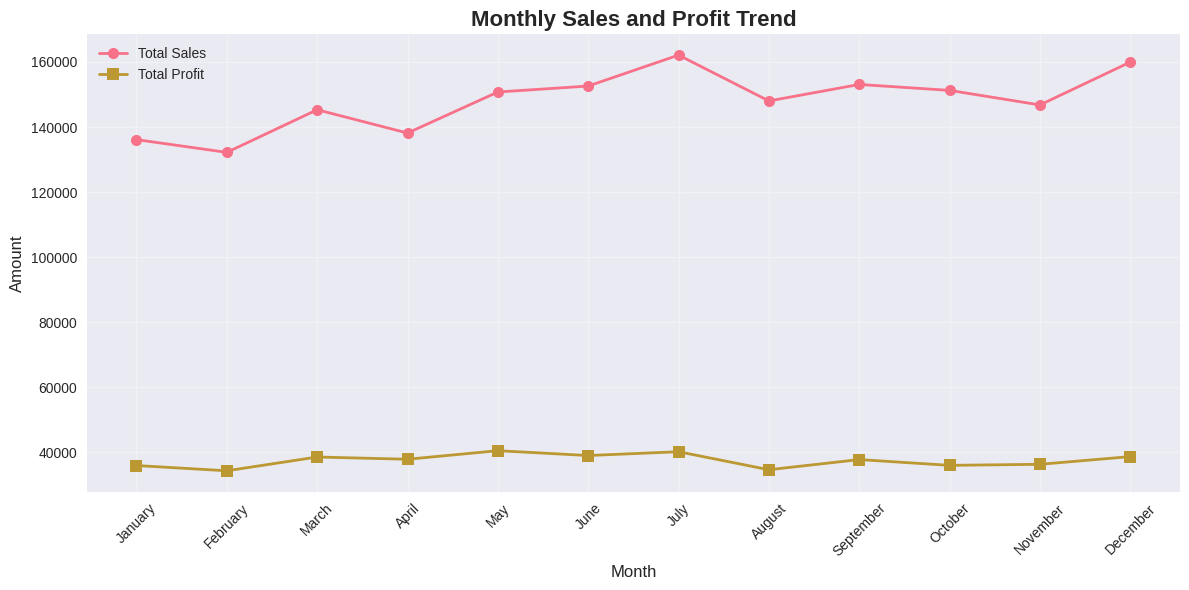

In [ ]:
#visualization 1: Monthly Sales Trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['MonthName'], monthly_sales['Sales'],
         marker='o',linewidth=2,markersize=8,label='Total Sales')
plt.plot(monthly_sales['MonthName'],monthly_sales['Profit'],
          marker='s',linewidth=2,markersize=8,label='Total Profit')
plt.title('Monthly Sales and Profit Trend', fontsize=16,fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount',fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

#Explanation: Ths cell analyzes performance across different product categories,sorts and sales andcreates a bar chart visualization total sales category.

In [ ]:
#cell 7:category performance analysis
print("=== Category performanceanalysis ===")

category_performance = df.groupby('Category').agg({
    'Sales' : 'sum',
    'Profit' : 'sum',
    'Quantity' : 'sum'
}).sort_values('Sales',ascending=False)

print("Category Performance (Sorted by Sales):")
print(category_performance)

=== Category performanceanalysis ===
Category Performance (Sorted by Sales):
                     Sales        Profit     Quantity
Category                                             
Books        370971.872558  92304.452141  3737.000000
Electronics  363354.096258  89894.080069  3587.000000
Clothing     350981.822773  90082.119920  3641.000000
Sports       346544.089186  90849.949134  3515.254425
Home Goods   344634.290152  86993.108551  3755.000000


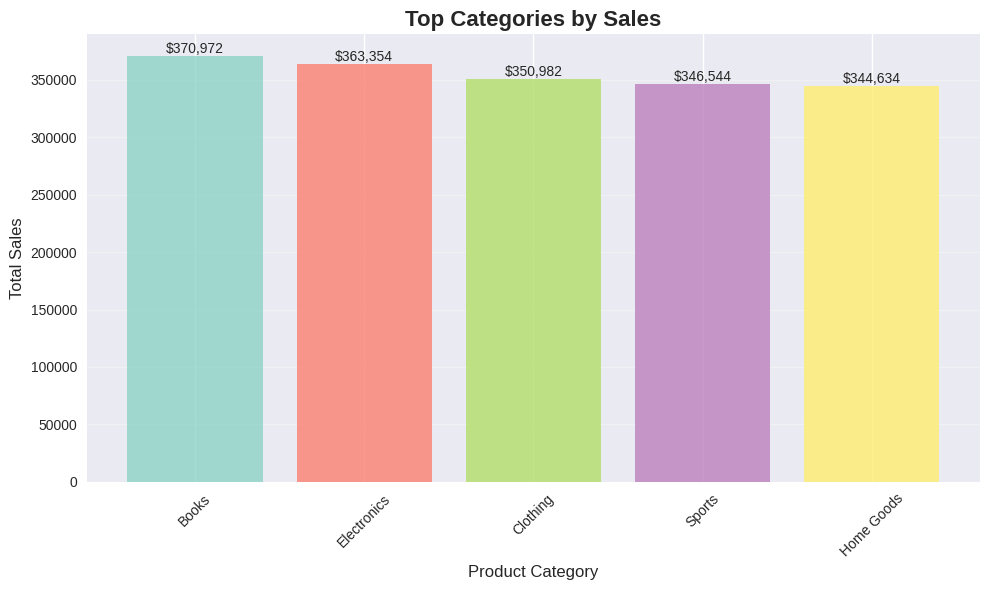

In [ ]:
#visualization 2: Top categories by sales
plt.figure(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(category_performance)))
bars = plt.bar(category_performance.index, category_performance['Sales'],color=colors , alpha=0.8)

#Add value labels on bars
for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, height, f'${height:,.0f}', ha='center', va='bottom',fontsize=10)

plt.title('Top Categories by Sales', fontsize=16,fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales',fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y' , alpha=0.3)
plt.tight_layout()
plt.show()


#Explanation: This cell analyses sales performance across different regions and creates apie chart showing the distibution of sales by region

In [ ]:
#cell 8: Regional Performance Analysis
print("=== Regional Performance Analysis")

regional_performance = df.groupby('Region').agg({
    'Sales' : ['sum' , 'mean' ,'count'],
    'Profit' : ['sum' , 'mean']
}).round(2)

print("Regional Performance:")
print(regional_performance)

=== Regional Performance Analysis
Regional Performance:
            Sales                   Profit        
              sum    mean count        sum    mean
Region                                            
East    392754.43  991.80   396   98782.42  249.45
North   448132.62  976.32   459  111889.29  243.77
South   466191.60  969.21   481  117316.01  243.90
West    469407.52  986.15   476  122135.99  256.59


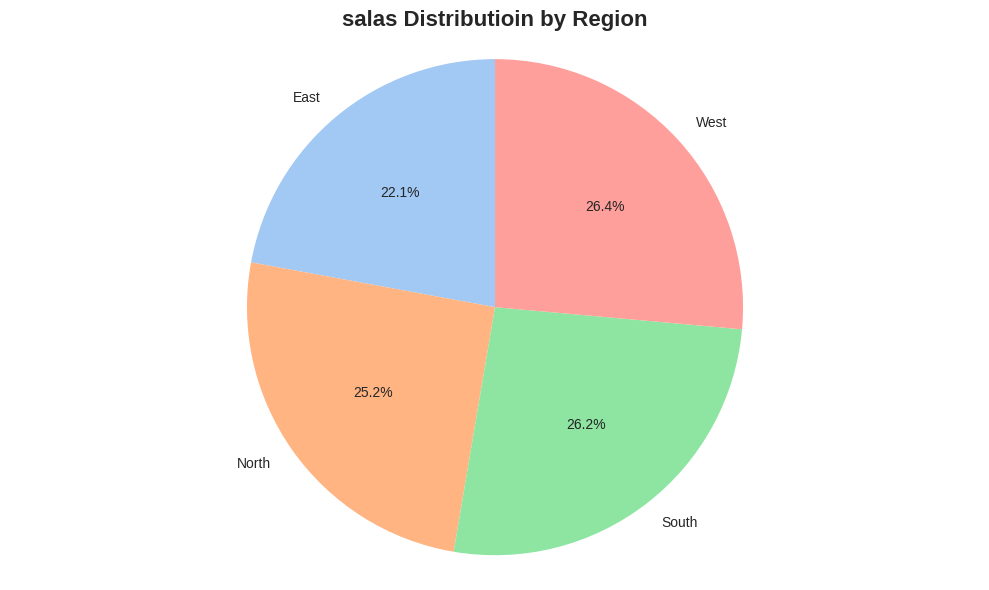

In [ ]:
#Visualization 3: Regional Sales Distribution
plt.figure(figsize=(10,6))
regional_data = df.groupby('Region')['Sales'].sum()
plt.pie(regional_data, labels=regional_data.index, autopct = '%1.1f%%',
        startangle=90, colors=sns.color_palette('pastel'))
plt.title('salas Distributioin by Region', fontsize=16,fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

#Explanation: This cell analyzes sales patterna by day of the week and creates a line chart showing how sales and profit vary throughout the week.

In [ ]:
#Day of week Analysis
print("=== Day of Week Analysis")

#Define proper order for day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Dayofweek'] = pd.Categorical(df['Dayofweek'], categories=day_order, ordered=True)

daily_performance = df.groupby('Dayofweek').agg({
    'Sales' : 'sum',
    'Profit' : 'sum',
    'Quantity' : 'sum'
}).round(2)

print("Day of Week Performance:")
print(daily_performance)

=== Day of Week Analysis
Day of Week Performance:
               Sales    Profit  Quantity
Dayofweek                               
Monday     253032.07  65078.94   2640.06
Tuesday    252332.24  62287.04   2661.06
Wednesday  247804.39  61222.61   2621.00
Thursday   250167.34  61598.23   2538.00
Friday     262035.11  67297.78   2581.00
Saturday   251949.01  65168.55   2498.06
Sunday     259166.01  67470.56   2696.06


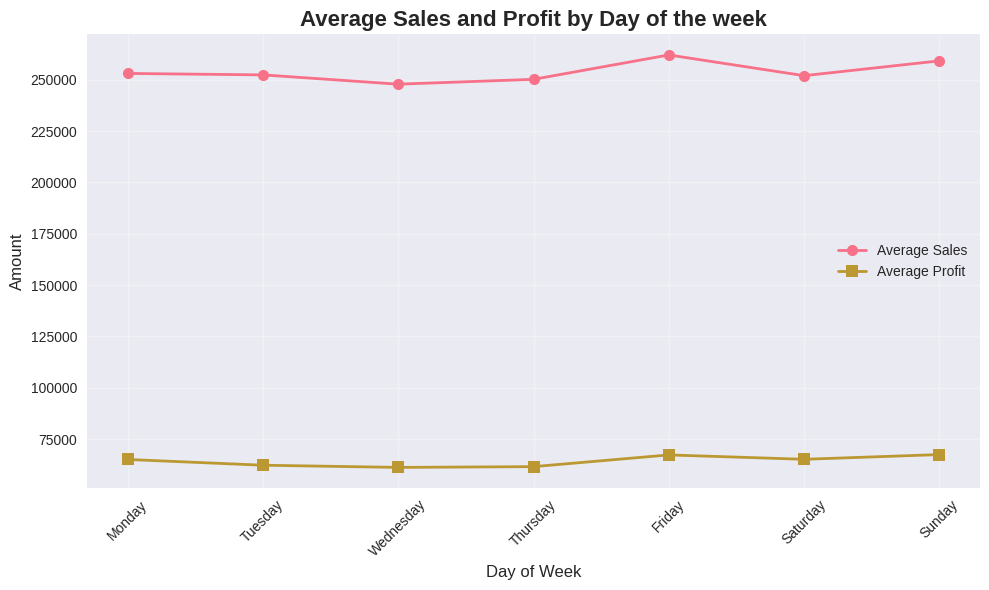

In [ ]:
#Visualization 4: Daily Sales Pattern
plt.figure(figsize=(10, 6))
plt.plot(daily_performance.index, daily_performance['Sales'],
         marker='o',linewidth=2,markersize=8,label='Average Sales')
plt.plot(daily_performance.index,daily_performance['Profit'],
          marker='s',linewidth=2,markersize=8,label='Average Profit')
plt.title('Average Sales and Profit by Day of the week', fontsize=16,fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Amount', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

#Explanation: This cell calculates coorelation between numerical variables and creates a map to visualize relationship between sales,quantity,profit, and time.


=== Correlation Analysis ===
Correlation Matrix:
             Sales  Quantity    Profit     Month
Sales     1.000000  0.055551  0.530968  0.066730
Quantity  0.055551  1.000000  0.029271  0.000278
Profit    0.530968  0.029271  1.000000 -0.031265
Month     0.066730  0.000278 -0.031265  1.000000


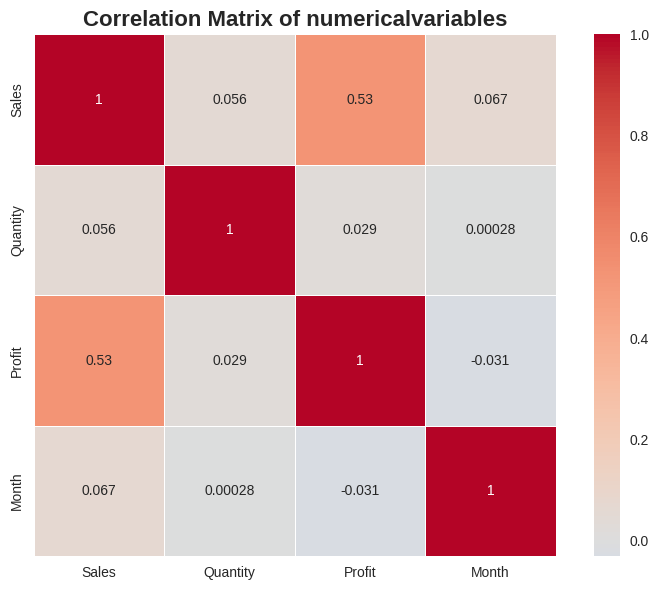

In [ ]:
#Correlation Analysis
print("=== Correlation Analysis ===")

#Select numerical colums for correlation
numerical_df = df[['Sales', 'Quantity', 'Profit', 'Month']]
correlation_matrix = numerical_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

#Heatmao Visualization
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',center=0, square="True", linewidths=0.5)
plt.title('Correlation Matrix of numericalvariables', fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

#Explanation: This cell creates a comprehensive 4_char dashboard that summarizes key vales from the previous analyses in a single view

=== 4-Chart mini Dashboard ===


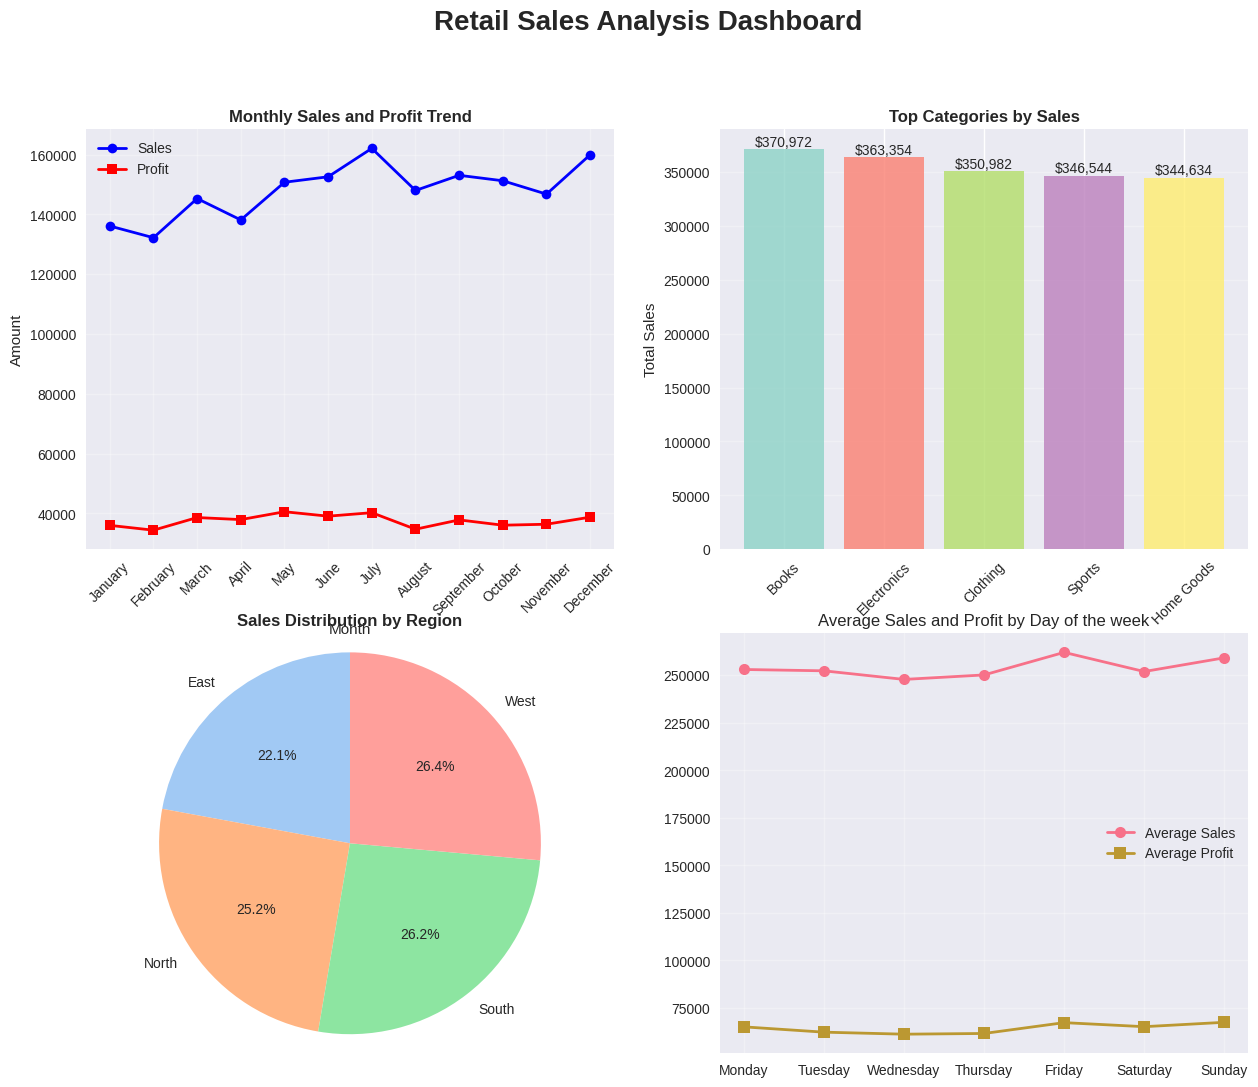

In [ ]:
#4-Chart mini Dashboard
print("=== 4-Chart mini Dashboard ===")

#Create a 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Retail Sales Analysis Dashboard', fontsize=20, fontweight='bold')

#Chart 1: Monthly Sales Trend(Top left)
axes[0,0].plot(monthly_sales['MonthName'], monthly_sales['Sales'],
               marker='o',linewidth=2,color='blue',label='Sales')
axes[0,0].plot(monthly_sales['MonthName'], monthly_sales['Profit'],
               marker='s',linewidth=2,color='red',label='Profit')
axes[0,0].set_title('Monthly Sales and Profit Trend',fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Amount')
axes[0,0].legend()
axes[0,0].grid(True,alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)

#Chart 2: Top Catagories(Top right)
colors = plt.cm.Set3(np.linspace(0, 1, len(category_performance)))
bars = axes[0,1].bar(category_performance.index, category_performance['Sales'],
                     color=colors , alpha=0.8)
for bar in bars:
  height = bar.get_height()
  axes[0,1].text(bar.get_x() + bar.get_width()/2, height, f'${height:,.0f}', ha='center', va='bottom',fontsize=10)
axes[0,1].set_title('Top Categories by Sales',fontweight='bold')
axes[0,1].set_xlabel('Product Category')
axes[0,1].set_ylabel('Total Sales')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y' , alpha=0.3)

#Chart 3: Regional Sales
regional_data = df.groupby('Region')['Sales'].sum()
axes[1,0].pie(regional_data, labels=regional_data.index, autopct = '%1.1f%%',
              startangle=90, colors=sns.color_palette('pastel'))
axes[1,0].set_title('Sales Distribution by Region',fontweight='bold')
axes[1,0].axis('equal')

#Char 4: DAy of the Week

axes[1,1].plot(daily_performance.index, daily_performance['Sales'],
         marker='o',linewidth=2,markersize=8,label='Average Sales')
axes[1,1].plot(daily_performance.index,daily_performance['Profit'],
          marker='s',linewidth=2,markersize=8,label='Average Profit')
axes[1,1].set_title('Average Sales and Profit by Day of the week')
#plt.xlabel('Day of Week', fontsize=12)
#plt.ylabel('Amount', fontsize=12)
#plt.xticks(rotation=45)
axes[1,1].legend()
axes[1,1].grid(True,alpha=0.3)
#plt.tight_layout()
#plt.show()


In [ ]:
#Key Insights and Business Recommendations
print("=== KEY INSIGHTS AND RECOMMENDATIONS ===")

print("\n KEY FINDINGS:")
print("1. Top Performing Category:", category_performance.index[0])
print("2. Best Performing Region:", regional_data.idxmax())
print("3. Highest Sales Month:", monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'MonthName'])
print("4. Best Day of Week", daily_performance['Sales'].idxmax())
print("5. Total Annual Sales: ${:,.2f}".format(df['Sales'].sum()))
print("6. Total Annual Profit: ${:,.2f}".format (df['Profit'].sum()))

print("\n BUSINESS RECOMMENDATIONS:")
print("1. Focus marketing efforts on", category_performance.index[0], "category")
print("2. Investigate performance in lower-performing regions")
print("3. Plan promotions around", daily_performance['Sales'].idxmax(), "to maximize sales")
print("4. Allocate inventory based on monthly trend patterns")
print("5. Monitor correlation between quantity and profit for pricing strategy")

print("\n PROFITABILITY ANALYSIS:")
profit_margin= (df['Profit'].sum() / df['Sales'].sum()) * 100
print(f"Overall Profit Margin: {profit_margin:.2f}%")

=== KEY INSIGHTS AND RECOMMENDATIONS ===

 KEY FINDINGS:
1. Top Performing Category: Books
2. Best Performing Region: West
3. Highest Sales Month: July
4. Best Day of Week Friday
5. Total Annual Sales: $1,776,486.17
6. Total Annual Profit: $450,123.71

 BUSINESS RECOMMENDATIONS:
1. Focus marketing efforts on Books category
2. Investigate performance in lower-performing regions
3. Plan promotions around Friday to maximize sales
4. Allocate inventory based on monthly trend patterns
5. Monitor correlation between quantity and profit for pricing strategy

 PROFITABILITY ANALYSIS:
Overall Profit Margin: 25.34%
